In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import sys
sys.path.append('../src') 

from model import TerrainGenerator
from config import LATENT_DIM, TILE_SIZE

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Testing on: {device}")

generator = TerrainGenerator(LATENT_DIM).to(device)

weights_path = '../models/generator.pth'
state_dict = torch.load(weights_path, map_location=device)

generator.load_state_dict(state_dict)
generator.eval()
print("Weights loaded successfully!")

Testing on: cuda
Weights loaded successfully!


In [12]:
noise = torch.randn(1, LATENT_DIM, 1, 1, device=device)

# Pass it through the generator (no gradients needed for testing)
with torch.no_grad():
    fake_terrain_tensor = generator(noise)

terrain_map = fake_terrain_tensor.squeeze().cpu().numpy()

print(f"Generated terrain shape: {terrain_map.shape}")
print(f"Elevation Min: {terrain_map.min():.2f}, Max: {terrain_map.max():.2f}")

Generated terrain shape: (3, 256, 256)
Elevation Min: 0.00, Max: 0.99


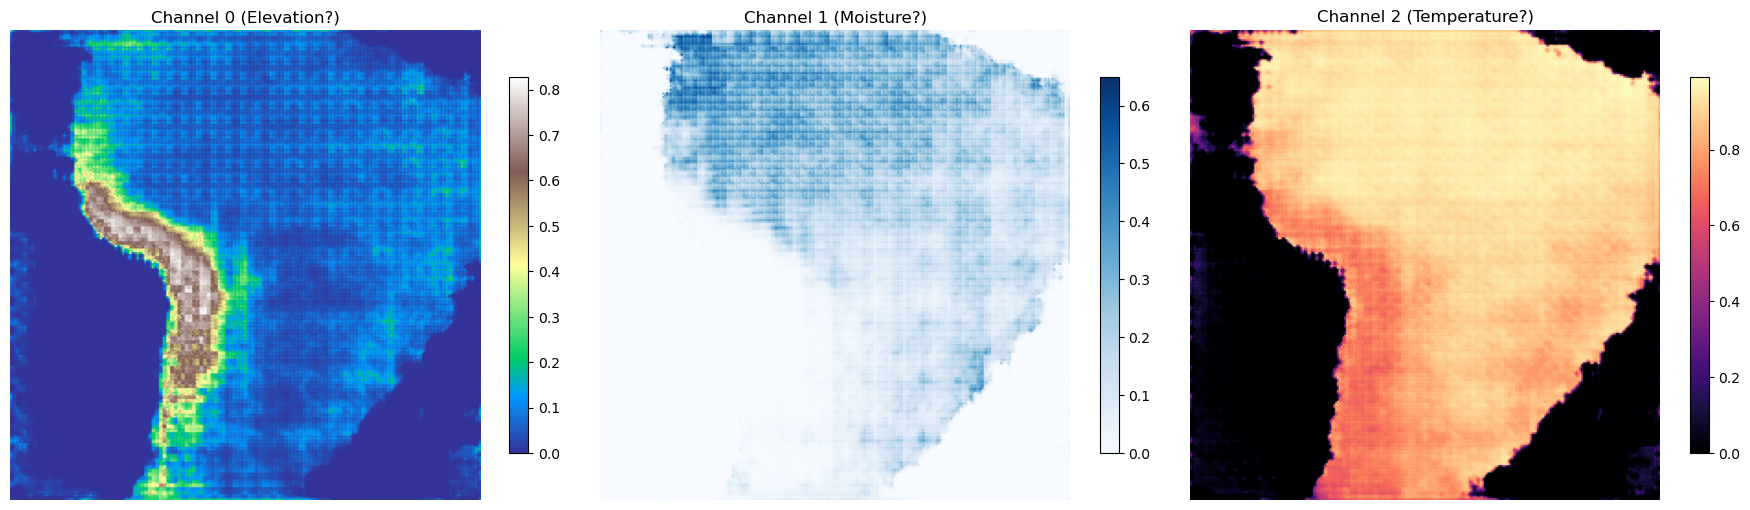

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(terrain_map[0], cmap='terrain')
axes[0].set_title("Channel 0 (Elevation?)")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(terrain_map[1], cmap='Blues')
axes[1].set_title("Channel 1 (Moisture?)")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(terrain_map[2], cmap='magma')
axes[2].set_title("Channel 2 (Temperature?)")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
import pyvista as pv
import numpy as np

pv.set_jupyter_backend('trame') 

elevation = terrain_map[0]

x = np.arange(0, elevation.shape[1], 1)
y = np.arange(0, elevation.shape[0], 1)
x, y = np.meshgrid(x, y)

z_exaggeration = 50.0 
z = elevation * z_exaggeration

grid = pv.StructuredGrid(x, y, z)

grid.point_data["Elevation"] = elevation.flatten(order="F")

plotter = pv.Plotter(window_size=[800, 600])

plotter.add_mesh(
    grid, 
    scalars="Elevation",
    cmap="terrain",
    show_edges=False,
    lighting=True
)

plotter.add_axes()
plotter.set_background('white')

plotter.show()

C:\Users\Orzeł\AppData\Local\Temp\ipykernel_7320\2924208182.py:15: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  grid = pv.StructuredGrid(x, y, z)


Widget(value='<iframe src="http://localhost:64041/index.html?ui=P_0x2cf99c3ead0_3&reconnect=auto" class="pyvis…